# Лабораторная работа 2
### "Распознование изображений"

Задание - создать 2 модели искусственных нейронных сетей (ИНС) для классификации изображений согласно заданию и вариантам.

Задачи работы:
1. Загрузить и обработать датасет согласно варианту.
2. Разделить данные на тренировочные и тестовые.
3. Обучить и простестировать линейную ИНС, вычислить точность на тренировочных/тестовых данных, при необходимости опираясь на материал практических занятий.
4. Обучить и протестировать модель ResNet18 или ResNet50 (на усмотрение студента), вычислить точность на тренировочных/тестовых данных.
5. Визуализировать один батч и продемонстрировать на нём классификацию изображений (см. раздел "Демонстрация работы ИНС на примере" далее)


Датасет (мой):

https://www.kaggle.com/competitions/mashtots-dataset-v2


Для реализации моделей ResNet50 или ResNet18 можно брать готовую архитектуру из библиотеки pyTorch.

В случае, если вы берёте ResNet из примера, замораживание весов может быть не обязательным (проверить!).

Контрольные вопросы - см. вопросы из ЛР1 и вопросы ниже:
1. В чем особенность архитектуры ResNet?
2. Какие стандарты цветовых моделей, помимо RGB, вы знаете?
3. Зачем мы используем функцию transform?
4. Какая библиотека в Python считывает изображения и в виде какого типа данных хранит их?
5. Требуется ли в этой работе разделять данные на тренировочные и тестовые?
6. Перемешивает ли даннные загрузчик (Dataloader)?


## 1. Загрузка датасета

In [1]:
!echo '{"username":"davidantonyan","key":"9aec456145fa8494b7c42a79d2fc5b6e"}' > kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!pip install kaggle -q
!kaggle competitions download -c mashtots-dataset-v2 --force
!unzip -q -o mashtots-dataset-v2.zip -d mashtots

100% 219M/219M [00:11<00:00, 20.5MB/s]



In [3]:
import os

# Исследуем структуру датасета
base_path = '/content/mashtots'
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}... и ещё {len(files)-3} файлов')

mashtots/
  sample_submission.csv
  Train/
    Train/
      44/
      59/
      4/
      63/
      50/
      5/
      31/
      12/
      56/
      76/
      38/
      57/
      60/
      47/
      26/
      45/
      62/
      51/
      10/
      28/
      25/
      75/
      22/
      55/
      77/
      14/
      66/
      46/
      8/
      70/
      17/
      39/
      72/
      16/
      73/
      54/
      48/
      9/
      64/
      34/
      69/
      6/
      52/
      27/
      2/
      29/
      65/
      23/
      49/
      21/
      58/
      37/
      33/
      61/
      42/
      43/
      74/
      30/
      41/
      11/
      53/
      36/
      13/
      24/
      19/
      0/
      1/
      7/
      67/
      32/
      3/
      15/
      68/
      71/
      20/
      35/
      18/
      40/
  new_test/
    new_test.csv


## 2. Подготовка данных

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from skimage import io
from sklearn.model_selection import train_test_split
import glob

# Проверяем доступность GPU
cuda0 = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Используемое устройство:', cuda0)

Используемое устройство: cuda:0


In [5]:
# Армянский алфавит (38 букв)
ARMENIAN_LETTERS = [
    'Ա', 'Բ', 'Գ', 'Դ', 'Ե', 'Զ', 'Է', 'Ը', 'Թ', 'Ժ',
    'Ի', 'Լ', 'Խ', 'Ծ', 'Կ', 'Հ', 'Ձ', 'Ղ', 'Ճ', 'Մ',
    'Յ', 'Ն', 'Շ', 'Ո', 'Չ', 'Պ', 'Ջ', 'Ռ', 'Ս', 'Վ',
    'Տ', 'Ր', 'Ց', 'Ու', 'Փ', 'Ք', 'Օ', 'Ֆ'
]

In [6]:
# Собираем все файлы и метки
# Структура датасета: train/<класс>/<файл>.png
train_path = '/content/mashtots/Train/Train'

all_files = []
all_labels = []

classes = sorted(os.listdir(train_path))
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
NUM_CLASSES = len(classes)

print(f'Количество классов: {NUM_CLASSES}')
print(f'Классы: {classes[:10]}...')

for cls in classes:
    cls_path = os.path.join(train_path, cls)
    if os.path.isdir(cls_path):
        for img_file in glob.glob(os.path.join(cls_path, '*.png')) + \
                         glob.glob(os.path.join(cls_path, '*.jpg')):
            all_files.append(img_file)
            all_labels.append(class_to_idx[cls])

print(f'Всего изображений: {len(all_files)}')

Количество классов: 78
Классы: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17']...
Всего изображений: 70060


In [7]:
# Сопоставляем индекс класса с армянской буквой
idx_to_letter = {}
for cls_name, idx in class_to_idx.items():
    try:
        letter_idx = int(cls_name) - 1  # папка "1" → ARMENIAN_LETTERS[0]
        idx_to_letter[idx] = ARMENIAN_LETTERS[letter_idx]
    except (ValueError, IndexError):
        idx_to_letter[idx] = cls_name  # запасной вариант

print("Пример маппинга:", {k: idx_to_letter[k] for k in list(idx_to_letter)[:5]})

Пример маппинга: {0: 'Ֆ', 1: 'Ա', 2: 'Ժ', 3: 'Ի', 4: 'Լ'}


In [8]:
# Разделяем на тренировочные, валидационные и тестовые данные (70% / 10% / 20%)
train_files, temp_files, train_labels, temp_labels = train_test_split(
    all_files, all_labels, test_size=0.3, random_state=42, stratify=all_labels
)
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.667, random_state=42, stratify=temp_labels
)

print(f'Тренировочных изображений:  {len(train_files)}')
print(f'Валидационных изображений:  {len(val_files)}')
print(f'Тестовых изображений:       {len(test_files)}')

Тренировочных изображений:  49042
Валидационных изображений:  6998
Тестовых изображений:       14020


In [9]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.size(0) == 1 else x),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [10]:
class LR2Dataset(Dataset):
    def __init__(self, file_list, answer_list, transform):
        self.file_list = file_list
        self.answer_list = answer_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        image = io.imread(self.file_list[idx])
        image = self.transform(image)
        label = self.answer_list[idx]
        return image, label

In [11]:
# Создаём датасеты
train_dataset = LR2Dataset(train_files, train_labels, transform)
val_dataset   = LR2Dataset(val_files,   val_labels,   transform)
test_dataset  = LR2Dataset(test_files,  test_labels,  transform)

# DataLoader-ы
BATCH_SIZE = 32
trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
valloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
testloader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('DataLoader-ы готовы.')
print(f'Батчей в trainloader: {len(trainloader)}')
print(f'Батчей в valloader: {len(valloader)}')
print(f'Батчей в testloader:  {len(testloader)}')

DataLoader-ы готовы.
Батчей в trainloader: 1533
Батчей в valloader: 219
Батчей в testloader:  439


## 3. Линейная (полносвязная) нейронная сеть

In [12]:
class LinearNet(nn.Module):
    """Линейная (многослойная полносвязная) нейронная сеть.
    Вход: 3 * 244 * 244 = 178_608 нейронов
    """
    def __init__(self, num_classes):
        super(LinearNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
          nn.Linear(3 * 64 * 64, 1024),
          nn.BatchNorm1d(1024),
          nn.ReLU(),
          nn.Dropout(0.2),
          nn.Linear(1024, 256),
          nn.BatchNorm1d(256),
          nn.ReLU(),
          nn.Dropout(0.2),
          nn.Linear(256, num_classes)
      )

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)


linear_net = LinearNet(NUM_CLASSES).to(cuda0)
print(linear_net)
total_params = sum(p.numel() for p in linear_net.parameters())
print(f'\nВсего параметров: {total_params:,}')

LinearNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Sequential(
    (0): Linear(in_features=12288, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=1024, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=78, bias=True)
  )
)

Всего параметров: 12,868,942


### 3.1 Обучение линейной ИНС

In [13]:
NUM_EPOCHS_LINEAR = 15

criterion = nn.CrossEntropyLoss()
optimizer_linear = optim.Adam(linear_net.parameters(), lr=1e-3)

train_losses_linear = []
val_losses_linear   = []

for epoch in range(NUM_EPOCHS_LINEAR):
    # Тренировка
    linear_net.train()
    running_loss     = 0.0
    running_corrects = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs = inputs.to(cuda0)
        labels = labels.to(cuda0)

        optimizer_linear.zero_grad()
        outputs = linear_net(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_linear.step()

        running_loss     += loss.item()
        running_corrects += torch.sum(preds == labels.data).item()

        if i % 50 == 49:
            avg_loss = running_loss / 50
            avg_acc  = running_corrects / (50 * BATCH_SIZE)
            print(f'  [Epoch {epoch+1}, Batch {i+1:4d}] loss: {avg_loss:.3f}  acc: {avg_acc:.3f}')
            train_losses_linear.append(avg_loss)
            running_loss     = 0.0
            running_corrects = 0

    # Валидация
    linear_net.eval()
    val_loss = 0.0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs = inputs.to(cuda0)
            labels = labels.to(cuda0)
            outputs = linear_net(inputs)
            val_loss    += criterion(outputs, labels).item()
            _, preds     = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    avg_val_loss = val_loss / len(valloader)
    avg_val_acc  = val_correct / val_total
    val_losses_linear.append(avg_val_loss)
    print(f'  [Epoch {epoch+1}] Val loss: {avg_val_loss:.3f}  Val acc: {avg_val_acc:.3f}')

  [Epoch 1, Batch   50] loss: 4.081  acc: 0.081
  [Epoch 1, Batch  100] loss: 3.578  acc: 0.159
  [Epoch 1, Batch  150] loss: 3.297  acc: 0.191
  [Epoch 1, Batch  200] loss: 3.095  acc: 0.228
  [Epoch 1, Batch  250] loss: 2.873  acc: 0.284
  [Epoch 1, Batch  300] loss: 2.771  acc: 0.290
  [Epoch 1, Batch  350] loss: 2.671  acc: 0.304
  [Epoch 1, Batch  400] loss: 2.626  acc: 0.315
  [Epoch 1, Batch  450] loss: 2.448  acc: 0.349
  [Epoch 1, Batch  500] loss: 2.432  acc: 0.354
  [Epoch 1, Batch  550] loss: 2.352  acc: 0.356
  [Epoch 1, Batch  600] loss: 2.345  acc: 0.376
  [Epoch 1, Batch  650] loss: 2.277  acc: 0.386
  [Epoch 1, Batch  700] loss: 2.161  acc: 0.412
  [Epoch 1, Batch  750] loss: 2.140  acc: 0.432
  [Epoch 1, Batch  800] loss: 2.138  acc: 0.402
  [Epoch 1, Batch  850] loss: 2.118  acc: 0.429
  [Epoch 1, Batch  900] loss: 2.027  acc: 0.460
  [Epoch 1, Batch  950] loss: 2.058  acc: 0.423
  [Epoch 1, Batch 1000] loss: 2.032  acc: 0.448
  [Epoch 1, Batch 1050] loss: 2.080  acc

### 3.2 Оценка точности линейной ИНС

In [14]:
def evaluate_model(model, loader, device, loader_name=''):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (preds == labels).sum().item()
    acc = correct / total
    print(f'Точность ({loader_name}): {acc:.4f}  ({correct}/{total})')
    return acc

# Точность линейной сети
linear_train_acc = evaluate_model(linear_net, trainloader, cuda0, 'тренировочная выборка')
linear_val_acc   = evaluate_model(linear_net, valloader,   cuda0, 'валидационная выборка')
linear_test_acc  = evaluate_model(linear_net, testloader,  cuda0, 'тестовая выборка')

Точность (тренировочная выборка): 0.8873  (43517/49042)
Точность (валидационная выборка): 0.6685  (4678/6998)
Точность (тестовая выборка): 0.6683  (9369/14020)


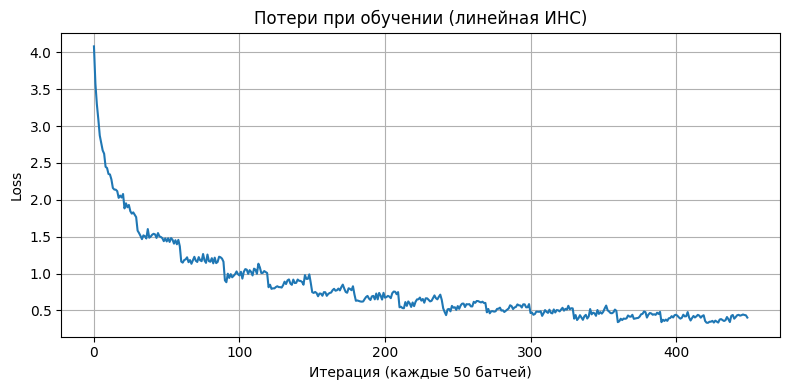

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_linear)
plt.title('Потери при обучении (линейная ИНС)')
plt.xlabel('Итерация (каждые 50 батчей)')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Сверточная нейронная сеть ResNet18

In [16]:
# Загружаем предобученную ResNet18
resnet = models.resnet18(pretrained=True)

# Заменяем последний полносвязный слой под наше количество классов
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, NUM_CLASSES)

resnet = resnet.to(cuda0)

print('ResNet18 готова.')
print(f'Последний слой: {resnet.fc}')
total_params = sum(p.numel() for p in resnet.parameters())
print(f'Всего параметров: {total_params:,}')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet18 готова.
Последний слой: Linear(in_features=512, out_features=78, bias=True)
Всего параметров: 11,216,526


### 4.1 Обучение ResNet18

In [17]:
NUM_EPOCHS_RESNET = 5

criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer_resnet, step_size=2, gamma=0.5)

train_losses_resnet = []
val_losses_resnet   = []

for epoch in range(NUM_EPOCHS_RESNET):
    # Тренировка
    resnet.train()
    running_loss     = 0.0
    running_corrects = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs = inputs.to(cuda0)
        labels = labels.to(cuda0)

        optimizer_resnet.zero_grad()
        outputs = resnet(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss     += loss.item()
        running_corrects += torch.sum(preds == labels.data).item()

        if i % 50 == 49:
            avg_loss = running_loss / 50
            avg_acc  = running_corrects / (50 * BATCH_SIZE)
            print(f'  [Epoch {epoch+1}, Batch {i+1:4d}] loss: {avg_loss:.3f}  acc: {avg_acc:.3f}')
            train_losses_resnet.append(avg_loss)
            running_loss     = 0.0
            running_corrects = 0

    # Валидация
    resnet.eval()
    val_loss    = 0.0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs = inputs.to(cuda0)
            labels = labels.to(cuda0)
            outputs = resnet(inputs)
            val_loss    += criterion_resnet(outputs, labels).item()
            _, preds     = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    avg_val_loss = val_loss / len(valloader)
    avg_val_acc  = val_correct / val_total
    val_losses_resnet.append(avg_val_loss)
    print(f'  [Epoch {epoch+1}] Val loss: {avg_val_loss:.3f}  Val acc: {avg_val_acc:.3f}')

    scheduler.step()

  [Epoch 1, Batch   50] loss: 4.216  acc: 0.066
  [Epoch 1, Batch  100] loss: 3.083  acc: 0.274
  [Epoch 1, Batch  150] loss: 2.142  acc: 0.486
  [Epoch 1, Batch  200] loss: 1.488  acc: 0.630
  [Epoch 1, Batch  250] loss: 1.160  acc: 0.704
  [Epoch 1, Batch  300] loss: 0.900  acc: 0.757
  [Epoch 1, Batch  350] loss: 0.801  acc: 0.777
  [Epoch 1, Batch  400] loss: 0.719  acc: 0.791
  [Epoch 1, Batch  450] loss: 0.724  acc: 0.797
  [Epoch 1, Batch  500] loss: 0.639  acc: 0.816
  [Epoch 1, Batch  550] loss: 0.571  acc: 0.839
  [Epoch 1, Batch  600] loss: 0.538  acc: 0.853
  [Epoch 1, Batch  650] loss: 0.555  acc: 0.841
  [Epoch 1, Batch  700] loss: 0.521  acc: 0.852
  [Epoch 1, Batch  750] loss: 0.563  acc: 0.836
  [Epoch 1, Batch  800] loss: 0.483  acc: 0.854
  [Epoch 1, Batch  850] loss: 0.510  acc: 0.857
  [Epoch 1, Batch  900] loss: 0.508  acc: 0.844
  [Epoch 1, Batch  950] loss: 0.459  acc: 0.871
  [Epoch 1, Batch 1000] loss: 0.446  acc: 0.876
  [Epoch 1, Batch 1050] loss: 0.441  acc

### 4.2 Оценка точности ResNet18

In [18]:
resnet_train_acc = evaluate_model(resnet, trainloader, cuda0, 'тренировочная выборка')
resnet_val_acc   = evaluate_model(resnet, valloader,   cuda0, 'валидационная выборка')
resnet_test_acc  = evaluate_model(resnet, testloader,  cuda0, 'тестовая выборка')

Точность (тренировочная выборка): 0.9911  (48607/49042)
Точность (валидационная выборка): 0.9423  (6594/6998)
Точность (тестовая выборка): 0.9404  (13185/14020)


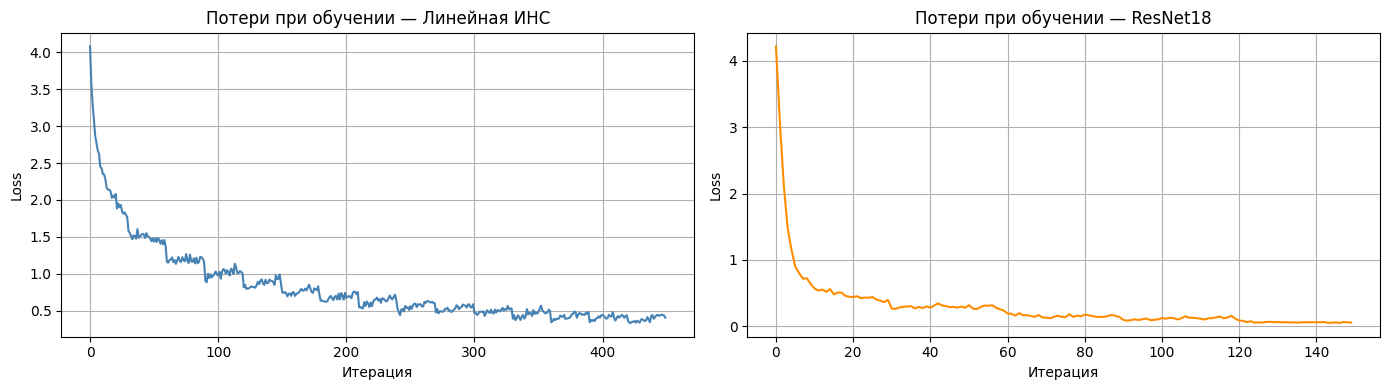


Итоговое сравнение моделей
Модель                  Train Acc     Test Acc
----------------------------------------------
Линейная ИНС               0.8873       0.6683
ResNet18                   0.9911       0.9404


In [19]:
# Сравниваем потери обеих моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses_linear, color='steelblue')
axes[0].set_title('Потери при обучении — Линейная ИНС')
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(train_losses_resnet, color='darkorange')
axes[1].set_title('Потери при обучении — ResNet18')
axes[1].set_xlabel('Итерация')
axes[1].set_ylabel('Loss')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Таблица результатов
print('\nИтоговое сравнение моделей')
print(f'{"Модель":<20} {"Train Acc":>12} {"Test Acc":>12}')
print('-' * 46)
print(f'{"Линейная ИНС":<20} {linear_train_acc:>12.4f} {linear_test_acc:>12.4f}')
print(f'{"ResNet18":<20} {resnet_train_acc:>12.4f} {resnet_test_acc:>12.4f}')

## 5. Демонстрация работы ИНС на примере

Здесь показана визуализация изображений из батча и их последующая классификация с помощью обученных моделей.

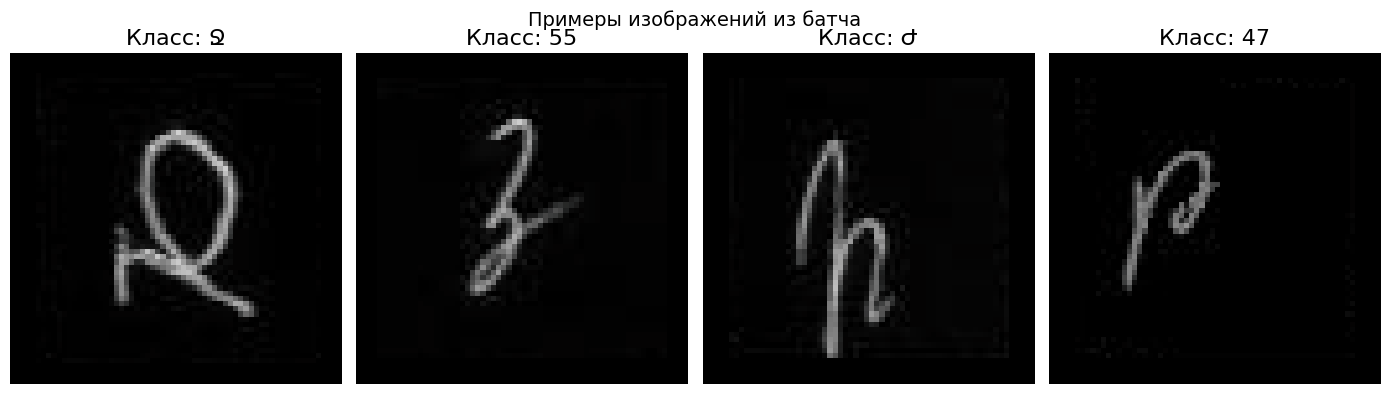

In [20]:
# Получаем один батч из тестового загрузчика
data_iter = iter(testloader)
data = next(data_iter)

# Вспомогательная функция: денормализация для корректного отображения
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

# Показываем первые 4 изображения из батча с армянскими буквами
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i in range(4):
    img = denormalize(data[0][i]).permute(1, 2, 0).numpy()
    true_letter = idx_to_letter[data[1][i].item()]
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'Класс: {true_letter}', fontsize=16)
plt.suptitle('Примеры изображений из батча', fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# Метки в батче
print('Истинные метки батча:', data[1][:8].tolist())

# Размерность тензора батча
print('Размерность батча:', data[0].size())

Истинные метки батча: [20, 51, 2, 42, 9, 8, 23, 59]
Размерность батча: torch.Size([32, 3, 64, 64])


In [22]:
# Классификация батча обоими моделями
linear_net.eval()
resnet.eval()

batch_inputs = data[0].to(cuda0)
true_labels  = data[1].tolist()

# Предсказания линейной сети
with torch.no_grad():
    preds_linear = torch.max(linear_net(batch_inputs), 1)[1].cpu().numpy()
    preds_resnet = torch.max(resnet(batch_inputs),     1)[1].cpu().numpy()

print('Классификация первых 8 изображений батча:')
print(f'{"#":<4} {"Истина":<12} {"Линейная":<12} {"ResNet18":<12}')
print('-' * 42)
for i in range(min(8, len(true_labels))):
    true_cls   = idx_to_class[true_labels[i]]
    lin_cls    = idx_to_class[preds_linear[i]]
    resnet_cls = idx_to_class[preds_resnet[i]]
    print(f'{i:<4} {true_cls:<12} {lin_cls:<12} {resnet_cls:<12}')

Классификация первых 8 изображений батча:
#    Истина       Линейная     ResNet18    
------------------------------------------
0    27           28           27          
1    55           6            20          
2    10           10           10          
3    47           71           47          
4    17           17           17          
5    16           16           16          
6    3            26           3           
7    62           62           62          


Путь к изображению: /content/mashtots/Train/Train/27/470.png
Истинный класс: 27


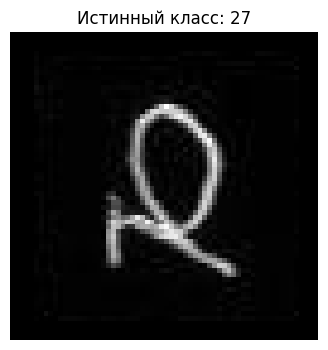

Размерность входного тензора: torch.Size([1, 3, 64, 64])

Предсказание линейной ИНС: 28
Предсказание ResNet18:     27
Истинный ответ:            27


In [24]:
# Демонстрация на одном конкретном изображении
# Берём первый файл из тестовой выборки
test_img_path = test_files[0]
true_label    = test_labels[0]

print(f'Путь к изображению: {test_img_path}')
print(f'Истинный класс: {idx_to_class[true_label]}')

# Отображаем
test_img_raw = plt.imread(test_img_path)
plt.figure(figsize=(4, 4))
plt.imshow(test_img_raw, cmap='gray' if test_img_raw.ndim == 2 else None)
plt.axis('off')
plt.title(f'Истинный класс: {idx_to_class[true_label]}')
plt.show()

# Трансформируем для нейросети
test_img_tensor = transform(io.imread(test_img_path))
test_img_tensor = test_img_tensor.reshape(1, 3, 64, 64).to(cuda0)
print('Размерность входного тензора:', test_img_tensor.size())

# Предсказания
with torch.no_grad():
    ans_linear = linear_net(test_img_tensor)
    ans_resnet = resnet(test_img_tensor)

pred_linear = idx_to_class[np.argmax(ans_linear.cpu().detach().numpy())]
pred_resnet = idx_to_class[np.argmax(ans_resnet.cpu().detach().numpy())]

print(f'\nПредсказание линейной ИНС: {pred_linear}')
print(f'Предсказание ResNet18:     {pred_resnet}')
print(f'Истинный ответ:            {idx_to_class[true_label]}')

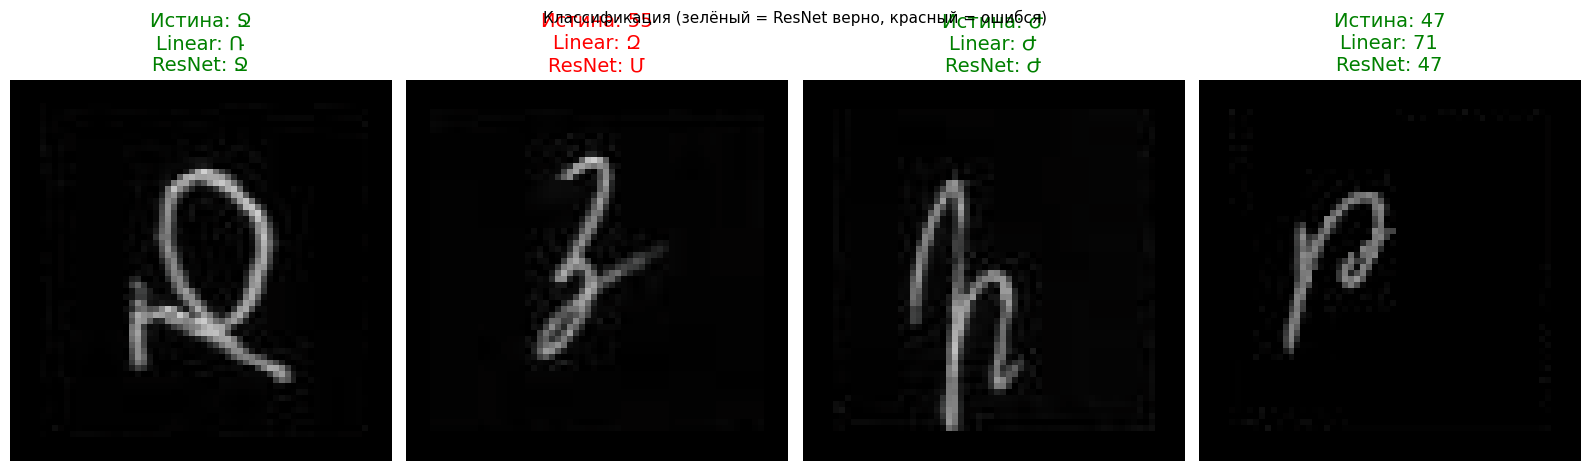

In [25]:
# Итоговая визуализация: предсказания обеих моделей с армянскими буквами
linear_net.eval()
resnet.eval()

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i in range(4):
    img = denormalize(data[0][i]).permute(1, 2, 0).numpy()
    true_letter   = idx_to_letter[data[1][i].item()]
    lin_letter    = idx_to_letter[preds_linear[i]]
    resnet_letter = idx_to_letter[preds_resnet[i]]

    axes[i].imshow(img)
    axes[i].axis('off')
    title = (
        f'Истина: {true_letter}\n'
        f'Linear: {lin_letter}\n'
        f'ResNet: {resnet_letter}'
    )
    color = 'green' if resnet_letter == true_letter else 'red'
    axes[i].set_title(title, fontsize=14, color=color)

plt.suptitle('Классификация (зелёный = ResNet верно, красный = ошибся)', fontsize=11)
plt.tight_layout()
plt.show()

## Ответы на контрольные вопросы

**1. В чем особенность архитектуры ResNet?**  
ResNet (Residual Network) вводит концепцию *остаточных соединений* (skip connections / shortcut connections): вход блока суммируется с его выходом, что позволяет градиентам свободно распространяться в глубоких сетях и избегает проблемы затухания градиента. Это позволяет успешно обучать сети глубиной 18, 50, 101 и более слоёв.

**2. Какие стандарты цветовых моделей, помимо RGB, вы знаете?**  
HSV (Hue, Saturation, Value), HSL (Hue, Saturation, Lightness), CMYK (Cyan, Magenta, Yellow, Key/Black), LAB (CIE L*a*b*), YCbCr, Grayscale.

**3. Зачем мы используем функцию transform?**  
Transform приводит изображения к единому стандарту, который ожидает нейросеть: стандартный размер (Resize + CenterCrop), тип данных float32 (ToTensor), и нормализованный диапазон (Normalize) с нулевым средним и единичным стандартным отклонением по каналам — так, как требует предобученная ImageNet-модель.

**4. Какая библиотека в Python считывает изображения и в виде какого типа данных хранит их?**  
В данной работе используется `skimage.io.imread` (библиотека scikit-image). Она возвращает изображение в виде `numpy.ndarray` с осями (H, W, C) и dtype uint8 (значения 0–255).

**5. Требуется ли в этой работе разделять данные на тренировочные и тестовые?**  
Да. Датасет Mashtots содержит только тренировочные данные, поэтому разделение на train/test выполняется вручную с помощью `train_test_split` (80%/20%) для объективной оценки обобщающей способности модели.

**6. Перемешивает ли данные загрузчик (Dataloader)?**  
Это определяется параметром `shuffle`. В данной работе: `trainloader` создан с `shuffle=True` (перемешивает перед каждой эпохой), `testloader` — с `shuffle=False` (порядок сохраняется для воспроизводимости оценки).